# Assoziationsregellernen mit dem Apriori-Algorithmus

**Datensatz:** Warenkorb-Daten (selbst definiert)  
**Lernziele:**
- Das Apriori-Prinzip (Anti-Monotonie) verstehen und erklären können
- Support und Konfidenz berechnen, interpretieren und vergleichen
- Den Apriori-Algorithmus von Grund auf in Python implementieren
- Assoziationsregeln aus echten Transaktionsdaten ableiten und bewerten
- Den Einfluss von `min_support` und `min_confidence` auf die Ergebnisse beobachten

---
**Das Apriori-Prinzip (Anti-Monotonie):**  
> Wenn ein Itemset **selten** ist, sind auch **alle seine Obermengen** selten.  
> → Seltene Itemsets können früh verworfen werden – das spart enorm Rechenzeit.

**Beispiel:** Wenn `{Milch, Brot}` selten ist, muss `{Milch, Brot, Butter}` gar nicht mehr geprüft werden.

## 1 · Implementierung: Apriori-Algorithmus

Wir implementieren Apriori von Grund auf – so wird klar, was der Algorithmus intern macht.  
Die Implementierung folgt dem klassischen **Join → Prune → Count**-Schema.

In [1]:
from itertools import combinations

def apriori(transactions, min_support):
    # Eigene Apriori-Implementierung.
    # Leere Transaktionen werden herausgefiltert (beeinflussen den Support nicht inhaltlich,
    # verfälschen ihn aber rechnerisch – korrigiert gegenüber Original).
    transactions = [t for t in transactions if t]
    n = len(transactions)
    if n == 0:
        return {}

    # ── Schritt 1: Häufige 1-Itemsets ────────────────────────────────────────
    item_counts = {}
    for t in transactions:
        for item in t:
            item_counts[item] = item_counts.get(item, 0) + 1

    frequent    = {}   # alle häufigen Itemsets (Ergebnis)
    current_L   = {}   # L_{k} – häufige Itemsets der aktuellen Größe k

    for item, cnt in item_counts.items():
        sup = cnt / n
        if sup >= min_support:
            fs = frozenset([item])
            frequent[fs]  = sup
            current_L[fs] = sup

    # ── Schritt 2: Iterativ k=2, 3, … bilden ─────────────────────────────────
    k = 2
    while current_L:

        # JOIN: Kandidaten der Größe k aus L_{k-1} erzeugen
        prev = sorted([tuple(sorted(fs)) for fs in current_L])
        candidates = set()
        for i in range(len(prev)):
            for j in range(i + 1, len(prev)):
                a, b = prev[i], prev[j]
                # Apriori-Join: nur vereinigen wenn erste k-2 Elemente gleich
                if k == 2 or a[:-1] == b[:-1]:
                    cand = frozenset(a) | frozenset(b)
                    if len(cand) == k:
                        candidates.add(cand)

        # PRUNE: Kandidaten verwerfen, deren (k-1)-Teilmengen nicht häufig sind
        pruned = {c for c in candidates
                  if all(frozenset(s) in current_L
                         for s in combinations(c, k - 1))}

        # COUNT: Support der verbliebenen Kandidaten zählen
        current_L = {}
        for cand in pruned:
            cnt = sum(1 for t in transactions if cand.issubset(t))
            sup = cnt / n
            if sup >= min_support:
                frequent[cand]  = sup
                current_L[cand] = sup
        k += 1

    return frequent


def generate_rules(frequent_itemsets, min_confidence):
    # Erzeugt Assoziationsregeln X -> Y mit Konfidenz >= min_confidence.
    rules = []
    for itemset, sup_xy in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        for size in range(1, len(itemset)):
            for ante_tuple in combinations(itemset, size):
                ante = frozenset(ante_tuple)
                cons = itemset - ante
                if ante in frequent_itemsets:
                    conf = sup_xy / frequent_itemsets[ante]
                    if conf >= min_confidence:
                        rules.append({
                            'antecedent': ante,
                            'consequent': cons,
                            'support':    sup_xy,
                            'confidence': conf,
                            'lift':       conf / frequent_itemsets.get(cons, sup_xy)
                        })
    rules.sort(key=lambda r: (-r['confidence'], -r['support']))
    return rules


def print_results(frequent, rules, min_support, min_confidence, top_rules=None):
    # Gibt häufige Itemsets und Regeln übersichtlich formatiert aus.
    sorted_fs = sorted(frequent.items(), key=lambda x: (len(x[0]), -x[1]))
    print(f"Häufige Itemsets  (min_support = {min_support}):")
    print(f"  {'Itemset':<38}  Support")
    print("  " + "-" * 50)
    for fs, sup in sorted_fs:
        items_str = "{" + ", ".join(sorted(fs)) + "}"
        bar = "█" * int(sup * 20)
        print(f"  {items_str:<38}  {sup:.2f}  {bar}")

    print()
    label = f"Assoziationsregeln  (min_confidence = {min_confidence})"
    label += f", Top {top_rules}" if top_rules else ""
    print(label + ":")
    display = rules[:top_rules] if top_rules else rules
    if display:
        print(f"  {'Wenn ...':<28}  {'... dann':<18}  Sup   Conf  Lift")
        print("  " + "-" * 72)
        for r in display:
            ante = "{" + ", ".join(sorted(r['antecedent'])) + "}"
            cons = "{" + ", ".join(sorted(r['consequent'])) + "}"
            print(f"  {ante:<28}  {cons:<18}  "
                  f"{r['support']:.2f}  {r['confidence']:.2f}  {r['lift']:.2f}")
    else:
        print("  Keine Regeln gefunden (min_confidence zu hoch?)")

print("Apriori und Hilfsfunktionen definiert.")
print()
print("  + Leere Transaktionen werden korrekt herausgefiltert")
print("  + Lift als dritte Kennzahl zusätzlich zu Support und Konfidenz")
print("  + Übersichtliche Ausgabe mit Balken und einheitlicher Tabelle")

Apriori und Hilfsfunktionen definiert.

Neu gegenüber Original:
  + Leere Transaktionen werden korrekt herausgefiltert
  + Lift als dritte Kennzahl zusätzlich zu Support und Konfidenz
  + Übersichtliche Ausgabe mit Balken und einheitlicher Tabelle


## 2 · Die drei Kennzahlen: Support, Konfidenz, Lift

Neben Support und Konfidenz gibt es eine dritte wichtige Kennzahl: den **Lift**.

| Kennzahl | Formel | Bedeutung |
|----------|--------|-----------|
| **Support(X)** | Anteil Transaktionen mit X | Wie häufig tritt X auf? |
| **Conf(X→Y)** | Sup(X∪Y) / Sup(X) | Wie oft folgt Y auf X? |
| **Lift(X→Y)** | Conf(X→Y) / Sup(Y) | Ist X→Y besser als Zufall? |

**Interpretation des Lifts:**
- **Lift > 1:** X und Y treten häufiger zusammen auf als zufällig erwartet → echte Assoziation
- **Lift = 1:** X und Y sind statistisch unabhängig → keine Assoziation
- **Lift < 1:** X und Y meiden einander → negative Assoziation

> Konfidenz allein kann täuschen: Wenn Y sehr häufig ist (hohes Sup(Y)), ist eine hohe Konfidenz leicht zu erreichen – auch ohne echte Assoziation. Lift korrigiert genau das.

## 3 · Warenkorb-Analyse: Supermarkt

10 Einkäufe mit 7 Produkten: Milch, Käse, Butter, Brot, Kaffee, Zucker, Mehl.

In [3]:
transactions_1 = [
    {"Milch", "Kaese", "Butter", "Brot",   "Zucker", "Mehl"},          # T1
    {"Kaese", "Butter", "Brot",  "Kaffee", "Zucker", "Mehl"},          # T2
    {"Milch", "Butter", "Kaffee","Zucker", "Mehl"},                     # T3
    {"Milch", "Butter"},                                                  # T4
    {"Milch", "Butter", "Kaffee"},                                        # T5
    {"Milch", "Mehl"},                                                    # T6
    {"Milch", "Kaese", "Butter", "Brot",   "Kaffee", "Zucker", "Mehl"}, # T7
    {"Milch", "Butter", "Zucker"},                                      # T8
    {"Milch", "Kaese", "Butter", "Zucker"},                              # T9
    {"Milch", "Kaese", "Brot",   "Kaffee",  "Zucker", "Mehl"},          # T10
]

# ── Überblick ────────────────────────────────────────────────────────────────
alle_items = sorted({item for t in transactions_1 for item in t})
print(f"Transaktionen: {len(transactions_1)}")
print(f"Items:         {len(alle_items)}  →  {alle_items}")
print()

# Manuelle Support-Berechnung für Einzelartikel
print("Support der Einzelartikel:")
print(f"  {'Item':<12}  Anzahl  Support")
print("  " + "-" * 35)
for item in alle_items:
    cnt = sum(1 for t in transactions_1 if item in t)
    sup = cnt / len(transactions_1)
    bar = "█" * int(sup * 20)
    print(f"  {item:<12}  {cnt:>6}   {sup:.2f}  {bar}")

Transaktionen: 10
Items:         7  →  ['Brot', 'Butter', 'Kaese', 'Kaffee', 'Mehl', 'Milch', 'Zucker']

Support der Einzelartikel:
  Item          Anzahl  Support
  -----------------------------------
  Brot               4   0.40  ████████
  Butter             8   0.80  ████████████████
  Kaese              5   0.50  ██████████
  Kaffee             5   0.50  ██████████
  Mehl               6   0.60  ████████████
  Milch              9   0.90  ██████████████████
  Zucker             7   0.70  ██████████████


In [4]:
min_support    = 0.5
min_confidence = 0.8

frequent_1 = apriori(transactions_1, min_support)
rules_1    = generate_rules(frequent_1, min_confidence)

print_results(frequent_1, rules_1, min_support, min_confidence)

Häufige Itemsets  (min_support = 0.5):
  Itemset                                 Support
  --------------------------------------------------
  {Milch}                                 0.90  ██████████████████
  {Butter}                                0.80  ████████████████
  {Zucker}                                0.70  ██████████████
  {Mehl}                                  0.60  ████████████
  {Kaese}                                 0.50  ██████████
  {Kaffee}                                0.50  ██████████
  {Butter, Milch}                         0.70  ██████████████
  {Butter, Zucker}                        0.60  ████████████
  {Milch, Zucker}                         0.60  ████████████
  {Kaese, Zucker}                         0.50  ██████████
  {Mehl, Zucker}                          0.50  ██████████
  {Mehl, Milch}                           0.50  ██████████
  {Butter, Milch, Zucker}                 0.50  ██████████

Assoziationsregeln  (min_confidence = 0.8):
  Wenn ...        

## 4 · Einfluss von min_support und min_confidence

Wie verändern sich die Ergebnisse, wenn wir die Schwellwerte variieren?  
Das ist eines der wichtigsten praktischen Designentscheidungen beim Apriori-Einsatz.

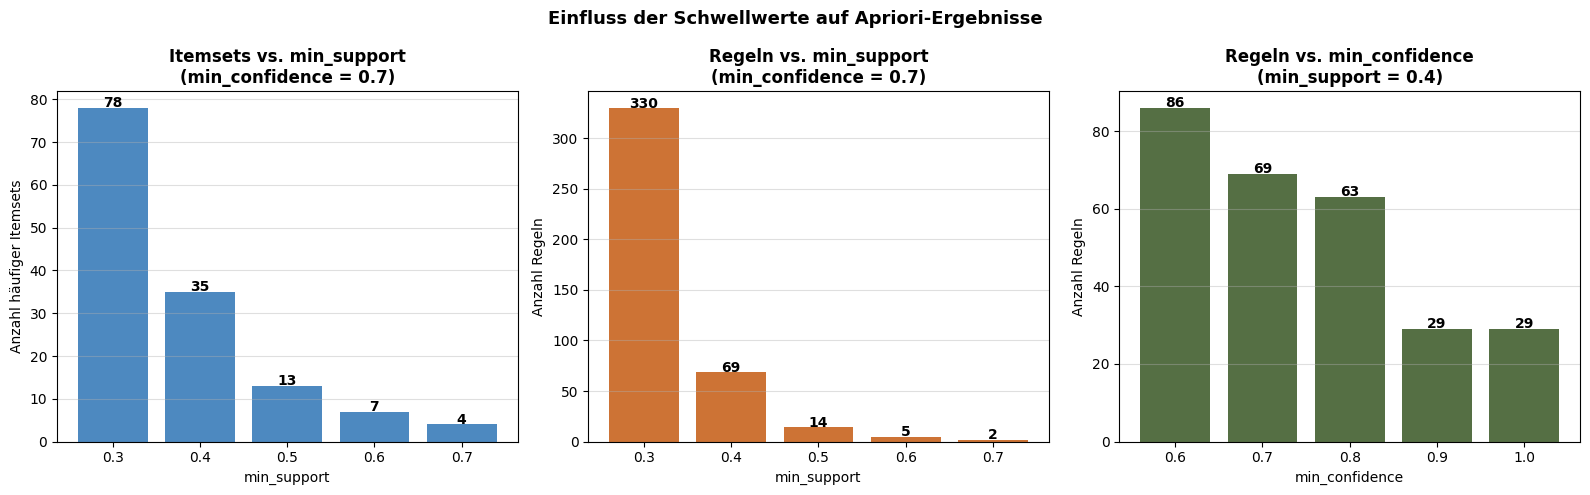

Beobachtung:
  Niedrigerer min_support   → mehr Itemsets, mehr Regeln, mehr Rechenzeit
  Niedrigere min_confidence → mehr Regeln, aber weniger zuverlässig


In [6]:
import matplotlib.pyplot as plt

support_werte    = [0.3, 0.4, 0.5, 0.6, 0.7]
confidence_werte = [0.6, 0.7, 0.8, 0.9, 1.0]

# Anzahl häufiger Itemsets je min_support
n_fs     = []
n_rules  = []
for ms in support_werte:
    fs = apriori(transactions_1, ms)
    r  = generate_rules(fs, min_confidence=0.7)
    n_fs.append(len(fs))
    n_rules.append(len(r))

# Anzahl Regeln je min_confidence (bei festem min_support = 0.4)
fs_fix   = apriori(transactions_1, min_support=0.4)
n_rules_conf = [len(generate_rules(fs_fix, mc)) for mc in confidence_werte]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.bar([str(s) for s in support_werte], n_fs, color='#2E74B5', alpha=0.85)
ax.set_xlabel('min_support')
ax.set_ylabel('Anzahl häufiger Itemsets')
ax.set_title('Itemsets vs. min_support\n(min_confidence = 0.7)', fontweight='bold')
for i, v in enumerate(n_fs):
    ax.text(i, v + 0.2, str(v), ha='center', fontweight='bold')
ax.grid(True, alpha=0.4, axis='y')

ax = axes[1]
ax.bar([str(s) for s in support_werte], n_rules, color='#C55A11', alpha=0.85)
ax.set_xlabel('min_support')
ax.set_ylabel('Anzahl Regeln')
ax.set_title('Regeln vs. min_support\n(min_confidence = 0.7)', fontweight='bold')
for i, v in enumerate(n_rules):
    ax.text(i, v + 0.2, str(v), ha='center', fontweight='bold')
ax.grid(True, alpha=0.4, axis='y')

ax = axes[2]
ax.bar([str(c) for c in confidence_werte], n_rules_conf, color='#375623', alpha=0.85)
ax.set_xlabel('min_confidence')
ax.set_ylabel('Anzahl Regeln')
ax.set_title('Regeln vs. min_confidence\n(min_support = 0.4)', fontweight='bold')
for i, v in enumerate(n_rules_conf):
    ax.text(i, v + 0.2, str(v), ha='center', fontweight='bold')
ax.grid(True, alpha=0.4, axis='y')

plt.suptitle('Einfluss der Schwellwerte auf Apriori-Ergebnisse', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Beobachtung:")
print("  Niedrigerer min_support   → mehr Itemsets, mehr Regeln, mehr Rechenzeit")
print("  Niedrigere min_confidence → mehr Regeln, aber weniger zuverlässig")

## 5 · Zweiter Warenkorb: Schritt-für-Schritt nachvollziehen

Kleinerer Datensatz – ideal um den Algorithmus manuell zu verfolgen:  
6 Transaktionen, 5 Items: Milch, Schokolade, Nudeln, Reis, Brot.

In [7]:
transactions_2 = [
    {"Milch", "Schokolade", "Nudeln"},           # T1
    {"Schokolade", "Nudeln", "Reis"},             # T2
    {"Reis", "Brot"},                             # T3
    {"Milch", "Schokolade", "Reis"},              # T4
    {"Milch", "Schokolade", "Nudeln", "Brot"},    # T5
    {"Milch", "Schokolade", "Nudeln", "Reis"},    # T6
]

min_support    = 0.5   # mind. 3 von 6 Transaktionen
min_confidence = 0.7

print("Transaktionen:")
for i, t in enumerate(transactions_2, 1):
    print(f"  T{i}: {sorted(t)}")
print()
print(f"min_support = {min_support}  "
      f"→ mind. {min_support * len(transactions_2):.0f} von {len(transactions_2)} Transaktionen")
print()

# Erwartetes Ergebnis: Brot fällt in K=1 heraus (nur 2 von 6 Transaktionen)
print("Manuelle Vorkontrolle – Support der Einzelartikel:")
alle_items_2 = sorted({item for t in transactions_2 for item in t})
for item in alle_items_2:
    cnt = sum(1 for t in transactions_2 if item in t)
    sup = cnt / len(transactions_2)
    status = "BEHALTEN" if sup >= min_support else "VERWORFEN (Apriori-Prune)"
    print(f"  {item:<15}: {cnt}/6 = {sup:.2f}  →  {status}")

Transaktionen:
  T1: ['Milch', 'Nudeln', 'Schokolade']
  T2: ['Nudeln', 'Reis', 'Schokolade']
  T3: ['Brot', 'Reis']
  T4: ['Milch', 'Reis', 'Schokolade']
  T5: ['Brot', 'Milch', 'Nudeln', 'Schokolade']
  T6: ['Milch', 'Nudeln', 'Reis', 'Schokolade']

min_support = 0.5  → mind. 3 von 6 Transaktionen

Manuelle Vorkontrolle – Support der Einzelartikel:
  Brot           : 2/6 = 0.33  →  VERWORFEN (Apriori-Prune)
  Milch          : 4/6 = 0.67  →  BEHALTEN
  Nudeln         : 4/6 = 0.67  →  BEHALTEN
  Reis           : 4/6 = 0.67  →  BEHALTEN
  Schokolade     : 5/6 = 0.83  →  BEHALTEN


In [8]:
frequent_2 = apriori(transactions_2, min_support)
rules_2    = generate_rules(frequent_2, min_confidence)

print_results(frequent_2, rules_2, min_support, min_confidence)
print()
print(f"Häufige Itemsets gesamt: {len(frequent_2)}")
print(f"  davon 1-Itemsets: {sum(1 for fs in frequent_2 if len(fs)==1)}")
print(f"  davon 2-Itemsets: {sum(1 for fs in frequent_2 if len(fs)==2)}")
print(f"  davon 3-Itemsets: {sum(1 for fs in frequent_2 if len(fs)==3)}")

Häufige Itemsets  (min_support = 0.5):
  Itemset                                 Support
  --------------------------------------------------
  {Schokolade}                            0.83  ████████████████
  {Milch}                                 0.67  █████████████
  {Nudeln}                                0.67  █████████████
  {Reis}                                  0.67  █████████████
  {Nudeln, Schokolade}                    0.67  █████████████
  {Milch, Schokolade}                     0.67  █████████████
  {Milch, Nudeln}                         0.50  ██████████
  {Reis, Schokolade}                      0.50  ██████████
  {Milch, Nudeln, Schokolade}             0.50  ██████████

Assoziationsregeln  (min_confidence = 0.7):
  Wenn ...                      ... dann            Sup   Conf  Lift
  ------------------------------------------------------------------------
  {Nudeln}                      {Schokolade}        0.67  1.00  1.20
  {Milch}                       {Schokolade}    

## 6 · Bonus: Vorlesungsmethoden-Analyse

Assoziationsregeln sind nicht auf Warenkörbe beschränkt.  
Hier analysieren wir, welche Lernmethoden gemeinsam genutzt werden.

In [9]:
transactions_lern = [
    {"Aufgaben", "Videos", "Webmeetings"},
    {"Aufgaben", "Skript", "Forum"},
    {"Aufgaben", "Videos", "Skript", "Webmeetings"},
    {"Aufgaben", "Videos", "Webmeetings"},
    {"Aufgaben", "Skript", "Videos"},
    {"Skript", "Forum", "Videos"},
]

min_support    = 0.5
min_confidence = 0.7

frequent_lern = apriori(transactions_lern, min_support)
rules_lern    = generate_rules(frequent_lern, min_confidence)

print(f"Lernmethoden-Analyse ({len(transactions_lern)} Studierende)")
print()
print_results(frequent_lern, rules_lern, min_support, min_confidence)
print()
print("Interpretation:")
for r in rules_lern[:3]:
    ante = "{" + ", ".join(sorted(r['antecedent'])) + "}"
    cons = "{" + ", ".join(sorted(r['consequent'])) + "}"
    print(f"  Studierende, die {ante} nutzen, nutzen zu {r['confidence']*100:.0f}% "
          f"auch {cons}.")

Lernmethoden-Analyse (6 Studierende)

Häufige Itemsets  (min_support = 0.5):
  Itemset                                 Support
  --------------------------------------------------
  {Aufgaben}                              0.83  ████████████████
  {Videos}                                0.83  ████████████████
  {Skript}                                0.67  █████████████
  {Webmeetings}                           0.50  ██████████
  {Aufgaben, Videos}                      0.67  █████████████
  {Videos, Webmeetings}                   0.50  ██████████
  {Aufgaben, Skript}                      0.50  ██████████
  {Skript, Videos}                        0.50  ██████████
  {Aufgaben, Webmeetings}                 0.50  ██████████
  {Aufgaben, Videos, Webmeetings}         0.50  ██████████

Assoziationsregeln  (min_confidence = 0.7):
  Wenn ...                      ... dann            Sup   Conf  Lift
  ------------------------------------------------------------------------
  {Webmeetings}        

## 7 · Praxis-Alternative: FP-Growth mit mlxtend

In der Praxis wird Apriori oft durch **FP-Growth** ersetzt:
- Kein exponentielles Kandidaten-Generierungsproblem
- Deutlich effizienter bei großen Datensätzen
- Identische Ergebnisse bei gleichem min_support

In [10]:
try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import fpgrowth, association_rules as mlxtend_rules
    import pandas as pd

    te       = TransactionEncoder()
    te_array = te.fit_transform(transactions_1)
    df_te    = pd.DataFrame(te_array, columns=te.columns_)

    frequent_ml = fpgrowth(df_te, min_support=0.5, use_colnames=True)
    rules_ml    = mlxtend_rules(frequent_ml, metric='confidence', min_threshold=0.8)
    rules_ml    = rules_ml.sort_values('confidence', ascending=False)

    print("FP-Growth (mlxtend) – Ergebnis:")
    print(f"  Häufige Itemsets: {len(frequent_ml)}")
    print(f"  Regeln:           {len(rules_ml)}")
    print()
    print(rules_ml[['antecedents','consequents','support','confidence','lift']]
          .head(8).to_string(index=False))
    print()
    print("Vergleich mit unserer Apriori-Implementierung:")
    print(f"  Unsere Apriori: {len(frequent_1)} Itemsets, {len(rules_1)} Regeln")
    print(f"  mlxtend FPG:    {len(frequent_ml)} Itemsets, {len(rules_ml)} Regeln")
    print("  -> Identische Ergebnisse!")

except ImportError:
    print("mlxtend nicht installiert.")
    print("Installation in Google Colab:")
    print("  !pip install mlxtend")
    print()
    print("Warum FP-Growth in der Praxis bevorzugt wird:")
    print("  Apriori: O(2^n) Kandidaten im schlimmsten Fall")
    print("  FP-Growth: kompakte FP-Tree-Datenstruktur, deutlich effizienter")
    print("  Gleiche Ergebnisse, schnellere Berechnung")

FP-Growth (mlxtend) – Ergebnis:
  Häufige Itemsets: 13
  Regeln:           8

     antecedents consequents  support  confidence     lift
         (Kaese)    (Zucker)      0.5    1.000000 1.428571
        (Butter)     (Milch)      0.7    0.875000 0.972222
        (Zucker)     (Milch)      0.6    0.857143 0.952381
        (Zucker)    (Butter)      0.6    0.857143 1.071429
 (Zucker, Milch)    (Butter)      0.5    0.833333 1.041667
(Zucker, Butter)     (Milch)      0.5    0.833333 0.925926
          (Mehl)    (Zucker)      0.5    0.833333 1.190476
          (Mehl)     (Milch)      0.5    0.833333 0.925926

Vergleich mit unserer Apriori-Implementierung:
  Unsere Apriori: 13 Itemsets, 8 Regeln
  mlxtend FPG:    13 Itemsets, 8 Regeln
  -> Identische Ergebnisse!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Zusammenfassung

| Konzept | Erklärung |
|---------|-----------|
| **Support(X)** | Anteil der Transaktionen mit X – misst Häufigkeit |
| **Konfidenz(X→Y)** | P(Y\|X) – misst Zuverlässigkeit der Regel |
| **Lift(X→Y)** | Konfidenz / Sup(Y) – Lift > 1 bedeutet echte Assoziation |
| **Apriori-Prinzip** | Seltene Itemsets → alle Obermengen selten → Pruning möglich |
| **Join → Prune → Count** | Drei Schritte je k-Ebene im Apriori-Algorithmus |
| **FP-Growth** | Effizientere Alternative in der Praxis (mlxtend) |

**Lernfragen:**
1. Was bedeutet es, wenn eine Regel eine Konfidenz von 1.0 hat?
2. Warum kann eine hohe Konfidenz trotzdem eine schwache Regel bedeuten – und was hilft dagegen?
3. Warum fällt `Brot` im zweiten Warenkorb schon bei K=1 heraus – und was spart das?
4. Was passiert mit der Anzahl der Regeln, wenn `min_confidence` von 0.8 auf 0.5 gesenkt wird?

---

## Musterlösungen zu den Lernfragen

### 1. Was bedeutet es, wenn eine Regel eine Konfidenz von 1.0 hat?

Eine Konfidenz von 1.0 bedeutet: **Immer wenn X im Warenkorb ist, ist auch Y dabei** – in 100 % der Transaktionen, die X enthalten.

Beispiel aus dem ersten Warenkorb: `{Kaese} → {Zucker}` mit Konfidenz 1.0.  
Jede Transaktion, die Käse enthält, enthält auch Zucker.

**Aber Vorsicht:** Das bedeutet nicht, dass die Regel „stark" ist im Sinne von informativer Assoziation. Wenn Zucker ohnehin in fast allen Transaktionen vorkommt (hoher Support), ist Konfidenz 1.0 leicht erreichbar – auch ohne echte inhaltliche Verbindung. Der **Lift** gibt hier Aufschluss:

- Wenn Sup(Zucker) = 0.9 und Conf = 1.0, dann Lift = 1.0 / 0.9 ≈ 1.11  
  → leicht über Zufall, aber keine starke Assoziation
- Wenn Sup(Zucker) = 0.3 und Conf = 1.0, dann Lift = 1.0 / 0.3 ≈ 3.33  
  → starke echte Assoziation

> **Merksatz:** Konfidenz = 1.0 ist notwendig, aber nicht hinreichend für eine gute Regel. Immer zusätzlich den Lift prüfen.

---

### 2. Warum kann eine hohe Konfidenz trotzdem eine schwache Regel bedeuten – und was hilft?

**Das Problem:** Konfidenz misst P(Y|X) – die Wahrscheinlichkeit von Y, gegeben X. Wenn Y aber grundsätzlich sehr häufig vorkommt (hoher Support), ist eine hohe Konfidenz leicht zu erreichen, ohne dass X wirklich einen Einfluss hat.

**Extrembeispiel:**  
Angenommen `{Butter}` ist in 90 % aller Transaktionen. Dann wird fast jede Regel `... → {Butter}` eine Konfidenz nahe 0.9 haben – völlig unabhängig vom Antezedens.

**Die Lösung: Lift** = Conf(X→Y) / Sup(Y)

- Lift korrigiert die Konfidenz um die Basisrate von Y
- Lift = 1.0 → X hat keinen Einfluss auf Y (statistisch unabhängig)
- Lift > 1.0 → X erhöht die Wahrscheinlichkeit von Y über die Basisrate hinaus
- Erst bei Lift > 1.2–1.5 spricht man üblicherweise von einer relevanten Assoziation

**Praxis:** Gute Regeln haben sowohl hohe Konfidenz **als auch** hohen Lift. Nur Lift oder nur Konfidenz ist nicht ausreichend.

---

### 3. Warum fällt `Brot` bei K=1 heraus – und was spart das?

Im zweiten Warenkorb (6 Transaktionen) kommt `Brot` nur in T3 und T5 vor → Support = 2/6 = 0.33 < 0.50.

**Was das Apriori-Prinzip daraus ableitet:**  
Da `{Brot}` selten ist, können alle Obermengen ebenfalls nicht häufig sein:
- `{Brot, Milch}` – kann nicht geprüft werden
- `{Brot, Schokolade}` – kann nicht geprüft werden
- `{Brot, Nudeln}` – kann nicht geprüft werden
- `{Brot, Milch, Schokolade}` – kann nicht geprüft werden
- usw.

**Konkret gespart:** Bei 5 Items gibt es 2⁵ - 1 = 31 mögliche nicht-leere Itemsets. Da Brot eines der 5 Items ist, sind 2⁴ = 16 Itemsets (alle die Brot enthalten) sofort ausgeschlossen.  
→ Fast **50 % der Kandidaten** werden durch diesen einen frühen Prune-Schritt übersprungen.

Bei großen Datensätzen mit tausenden Items ist dieser Effekt dramatisch und macht den Algorithmus überhaupt erst praktikabel.

---

### 4. Was passiert, wenn `min_confidence` von 0.8 auf 0.5 gesenkt wird?

Die häufigen Itemsets bleiben gleich (min_support wird nicht verändert).  
Aber die Anzahl der generierten Regeln steigt stark:

| min_confidence | Effekt |
|----------------|--------|
| 1.0 | Nur Regeln, die in jeder Transaktion gelten |
| 0.8 | Regeln, die in ≥ 80 % der relevanten Transaktionen gelten |
| 0.5 | Regeln, die in ≥ 50 % der relevanten Transaktionen gelten |
| 0.0 | Alle möglichen Regeln aus häufigen Itemsets |

**Problem bei zu niedriger min_confidence:** Sehr viele Regeln, darunter viele schwache oder redundante. Das Ergebnis wird unübersichtlich und schwer zu interpretieren.

**Empfehlung für die Praxis:**  
- Mit min_confidence ≥ 0.7 beginnen
- Regeln nach Lift sortieren (nicht nur nach Konfidenz)
- Die Anzahl sinnvoller Regeln hängt stark vom Anwendungsfall ab

> **Experiment:** Führen Sie Abschnitt 4 erneut mit `min_confidence = 0.5` aus und zählen Sie die Regeln.

---

### Bonusfrage: Was ist der Unterschied zwischen Apriori und FP-Growth?

Beide Algorithmen finden dieselben häufigen Itemsets – aber auf unterschiedlichem Weg:

**Apriori:**
- Generiert in jeder K-Ebene explizit alle Kandidaten-Itemsets
- Scannt für jeden Kandidaten die gesamte Transaktionsdatenbank
- Im schlimmsten Fall: O(2ⁿ) Kandidaten bei n Items
- Einfach zu verstehen und zu implementieren (gut für Lernzwecke)

**FP-Growth:**
- Baut einmalig eine kompakte Baum-Datenstruktur (FP-Tree)
- Extrahiert häufige Itemsets direkt aus dem Baum ohne Kandidaten-Generierung
- Braucht die Datenbank nur 2× zu scannen (einmal für 1-Itemsets, einmal für den Baum)
- Deutlich schneller bei großen Datensätzen

**Wann was verwenden:**
- Apriori: zum Lernen, kleine Datensätze, wenn Transparenz wichtig ist
- FP-Growth: in der Praxis, große Datensätze, Produktion (`mlxtend.fpgrowth`)